Custom: -0.3521868654888828 6.954622942240306
Numpy: -0.3521868654888831 6.9546229422403085
Largest residual: 6.973680290593639 9.6750973243421 5.1765129845675695
Smallest residual: 7.860643052769538 4.695558112758079 0.5093504079996398


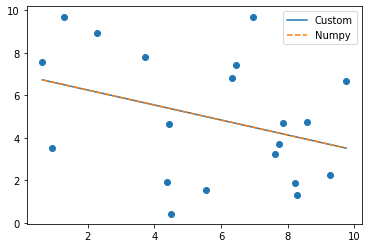

True: 2.5 -0.4
Custom: 2.424021292066086 -0.42405039952219636
Numpy: 2.424021292066087 -0.42405039952219753
Largest residual: 0.96 2.9171184264828907 1.0141083856216446
Smallest residual: 0.7000000000000001 1.2615525796672222 -0.011211925256842115


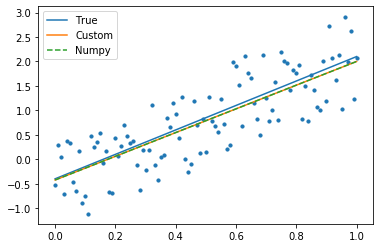

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# custom least squares
def custom_ls(x, y):
    n = len(x)
    sx = np.sum(x)
    sy = np.sum(y)
    sxx = np.sum(x*x)
    sxy = np.sum(x*y)

    m = (n*sxy - sx*sy) / (n*sxx - sx*sx)
    b = (sy/n) - m*(sx/n)

    return m, b


rng = np.random.default_rng(42)

# random x,y test
X = rng.uniform(0,10,20)
X.sort()
Y = rng.uniform(0,10,20)

m1, b1 = custom_ls(X,Y)

A = np.vstack([X, np.ones(len(X))]).T
m_np, b_np = np.linalg.lstsq(A,Y,rcond=None)[0]

print("Custom:",m1,b1)
print("Numpy:",m_np,b_np)

res = Y - (m1*X + b1)

imax = np.argmax(abs(res))
imin = np.argmin(abs(res))

print("Largest residual:",X[imax],Y[imax],res[imax])
print("Smallest residual:",X[imin],Y[imin],res[imin])

plt.scatter(X,Y)
plt.plot(X,m1*X+b1,label="Custom")
plt.plot(X,m_np*X+b_np,'--',label="Numpy")
plt.legend()
plt.show()


#line test
m_true = 2.5
b_true = -0.4

X2 = np.arange(0,1.01,0.01)

noise = rng.uniform(-1,1,len(X2))
Y2 = m_true*X2 + b_true + noise

m2,b2 = custom_ls(X2,Y2)

A2 = np.vstack([X2,np.ones(len(X2))]).T
m2_np,b2_np = np.linalg.lstsq(A2,Y2,rcond=None)[0]

print("True:",m_true,b_true)
print("Custom:",m2,b2)
print("Numpy:",m2_np,b2_np)

res2 = Y2 - (m2*X2 + b2)

imax = np.argmax(abs(res2))
imin = np.argmin(abs(res2))

print("Largest residual:",X2[imax],Y2[imax],res2[imax])
print("Smallest residual:",X2[imin],Y2[imin],res2[imin])

plt.scatter(X2,Y2,s=10)
plt.plot(X2,m_true*X2+b_true,label="True")
plt.plot(X2,m2*X2+b2,label="Custom")
plt.plot(X2,m2_np*X2+b2_np,'--',label="Numpy")
plt.legend()
plt.show()

###### 